# Project 2: Dropout Classifier
# Task 1 & 2 — Data Preprocessing, Cleaning, Exploration & Correlation
This notebook loads the student dataset, cleans it, explores it, and visualizes correlations.

Install & Import Libraries

In this step, we import the libraries required for loading, cleaning, and visualizing the dataset.
Pandas and NumPy help with data handling, Matplotlib and Seaborn are used for plots, 
and scikit-learn tools are included for preprocessing if needed later.


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, pickle
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline


###  Load Raw Dataset

Here we load the original student dataset, which is separated by semicolons.  
We display the first few rows to understand the structure and confirm that the data has been imported correctly.


In [4]:
df = pd.read_csv("data.csv", sep=";")
import os
os.listdir()
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


###  Data Cleaning Steps

In this part, we perform basic cleaning:

• remove unwanted index columns  
• tidy the column names  
• convert the Target column into a categorical variable

These steps make the dataset easier to work with and ensure consistency for later analysis.


In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.strip().str.replace('\t', '', regex=True)
df['Target'] = df['Target'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital status                                  4424 non-null   int64   
 1   Application mode                                4424 non-null   int64   
 2   Application order                               4424 non-null   int64   
 3   Course                                          4424 non-null   int64   
 4   Daytime/evening attendance                      4424 non-null   int64   
 5   Previous qualification                          4424 non-null   int64   
 6   Previous qualification (grade)                  4424 non-null   float64 
 7   Nacionality                                     4424 non-null   int64   
 8   Mother's qualification                          4424 non-null   int64   
 9   Father's qualification        

###  Save Clean Dataset

In [6]:
df.to_csv("data_clean.csv", index=False)
print("Cleaned data saved as data_clean.csv")

Cleaned data saved as data_clean.csv


###  Missing Values & Summary

We check the dataset for missing values to ensure the data is complete.  
This step helps us confirm that there are no gaps that could affect model performance or analysis.


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital status                                  4424 non-null   int64   
 1   Application mode                                4424 non-null   int64   
 2   Application order                               4424 non-null   int64   
 3   Course                                          4424 non-null   int64   
 4   Daytime/evening attendance                      4424 non-null   int64   
 5   Previous qualification                          4424 non-null   int64   
 6   Previous qualification (grade)                  4424 non-null   float64 
 7   Nacionality                                     4424 non-null   int64   
 8   Mother's qualification                          4424 non-null   int64   
 9   Father's qualification        

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

###  Descriptive Statistics

We generate descriptive statistics for all features to understand their range, distribution,
and general behavior.  
This helps us identify potential outliers and get an overview of the dataset.


In [8]:
df.describe(include='all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


### Student Outcome Distribution

Here we check how many students graduated, enrolled, or dropped out.
This gives a quick idea of the overall balance in the dataset and helps us see
which outcome is most common.

C:\Users\Manas\AppData\Local\Temp\ipykernel_14152\2981300071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', palette='viridis')


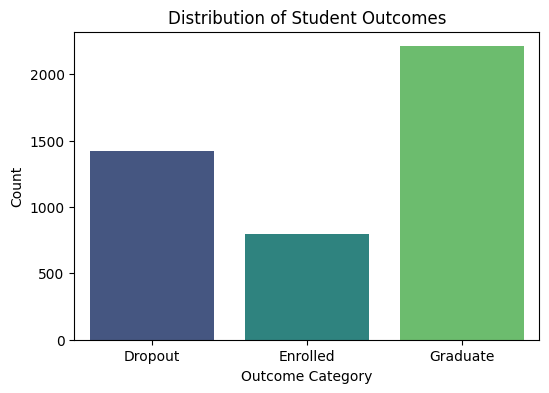

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target', palette='viridis')
plt.title("Distribution of Student Outcomes")
plt.xlabel("Outcome Category")
plt.ylabel("Count")
plt.show()


###  Histogram of Numerical Features

We visualize numerical features using histograms to see how the data is distributed.  
This gives us a better sense of skewness, dominant values, and patterns across different variables.


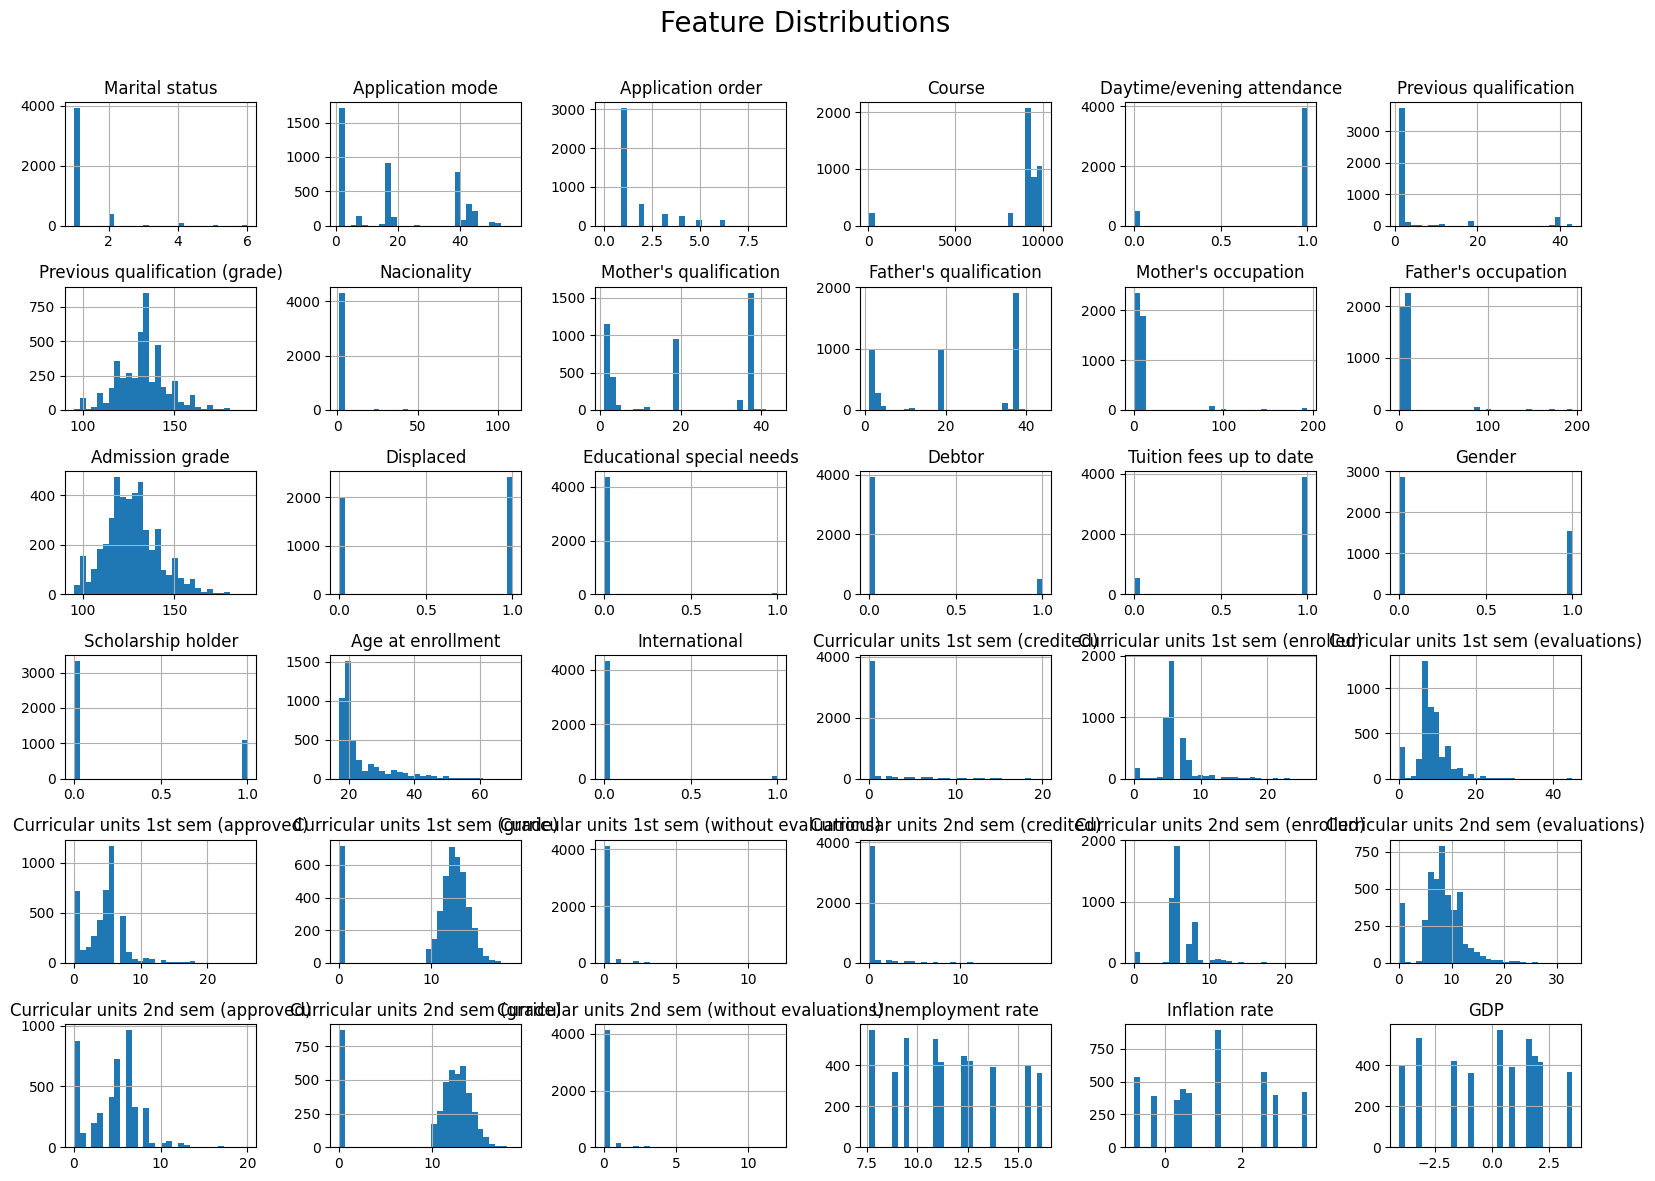

In [11]:
df.hist(figsize=(16,12), bins=30)
plt.suptitle('Feature Distributions', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

###  Correlation Heatmap

To understand relationships between features, we compute a correlation matrix and display it
as a heatmap.  
This helps identify which variables are related and whether any strong correlations exist
that may influence model building.


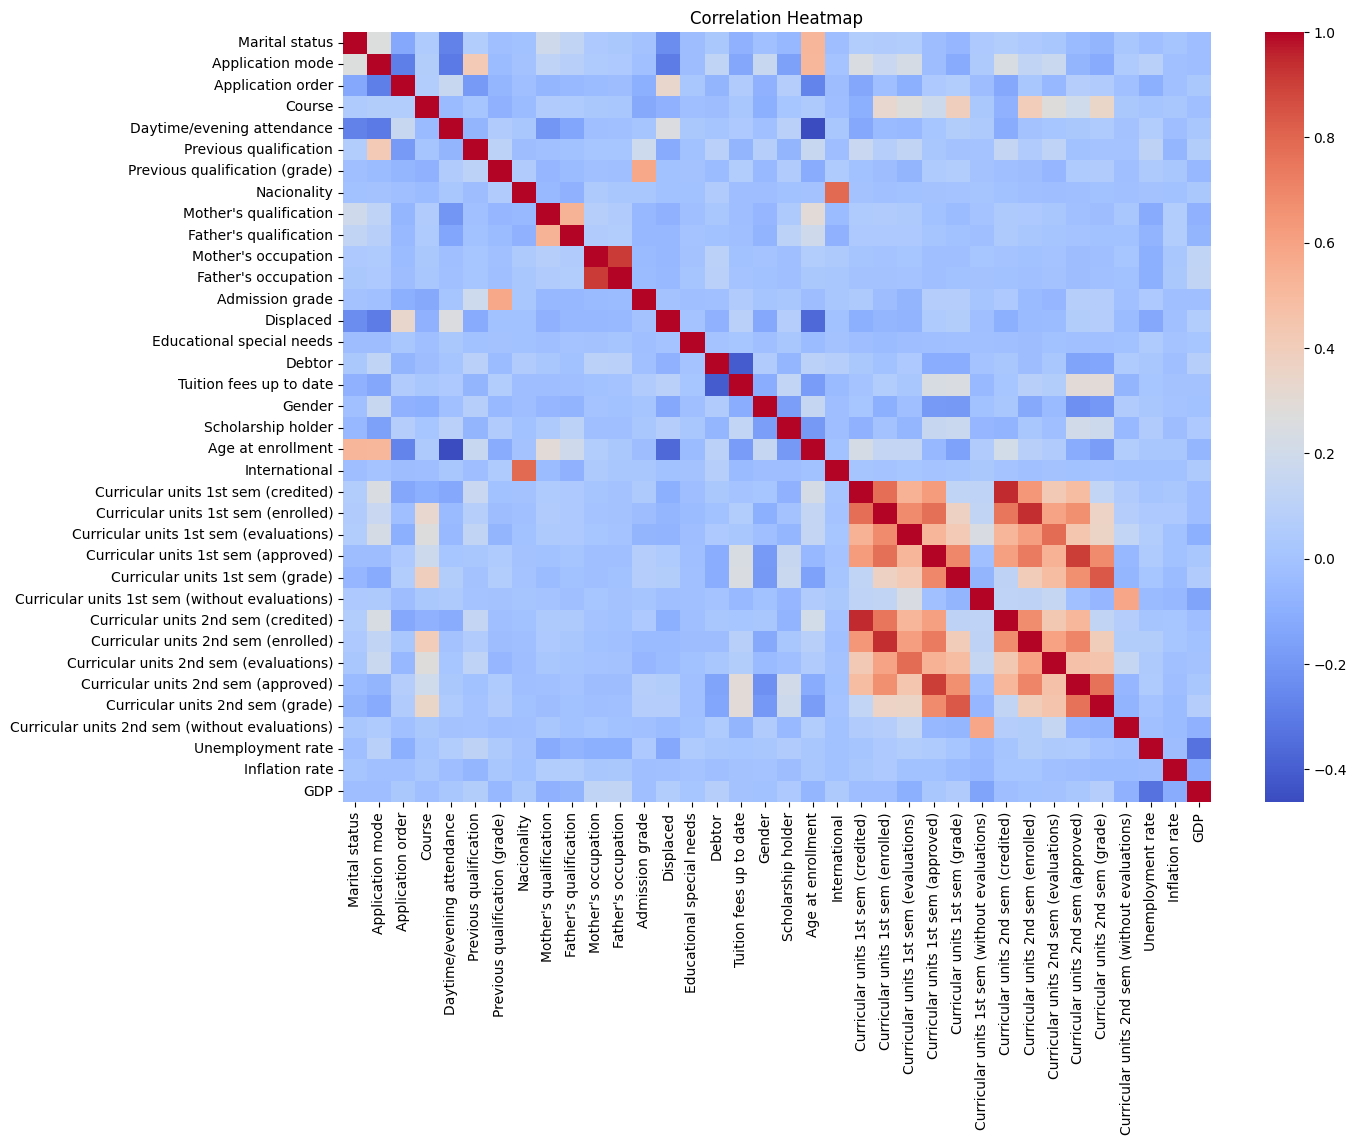

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

###  Correlation with Target

In this step, we convert the Target column into numeric values so that correlations can be calculated.
We then measure how strongly each numerical feature is related to the final student outcome 
(Dropout, Enrolled, Graduate).  
Sorting the correlations helps us identify which variables have the highest influence on the target.


In [13]:
target_map = {'Dropout':0, 'Graduate':1, 'Enrolled':2}
df['Target_num'] = df['Target'].map(target_map)
corr_target = numeric_df.corrwith(df['Target_num']).sort_values(ascending=False)
corr_target

Curricular units 2nd sem (grade)                  0.429214
Curricular units 2nd sem (approved)               0.351135
Curricular units 1st sem (grade)                  0.349652
Tuition fees up to date                           0.342121
Curricular units 1st sem (approved)               0.290243
Curricular units 2nd sem (evaluations)            0.194412
Curricular units 1st sem (evaluations)            0.125278
Scholarship holder                                0.114517
Displaced                                         0.070649
Daytime/evening attendance                        0.066439
Curricular units 2nd sem (enrolled)               0.060670
Curricular units 1st sem (enrolled)               0.052020
Mother's occupation                               0.051664
Father's occupation                               0.051455
Admission grade                                   0.038716
GDP                                               0.037052
Application order                                 0.0273

### Compare Average Grades by Outcome

Here we just check how the admission grades look for students who
dropped out, enrolled, or graduated.
This helps us quickly see if students with higher grades are more likely to finish,
and if lower grades are linked to dropout.

C:\Users\Manas\AppData\Local\Temp\ipykernel_14152\1492979080.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Admission grade', palette='Set2')


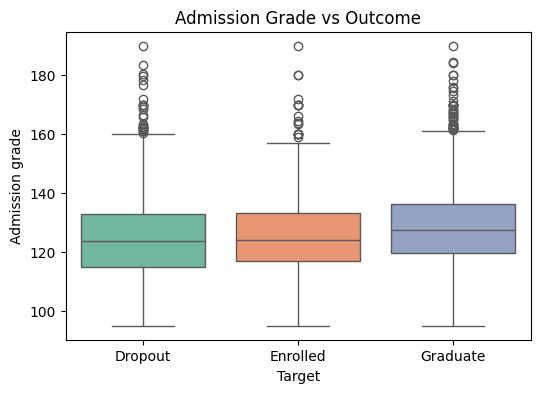

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Target', y='Admission grade', palette='Set2')
plt.title("Admission Grade vs Outcome")
plt.show()


### : Model Training, Evaluation & Persisting Best Model
This notebook continues from data preprocessing and trains multiple machine learning models.

### Load Clean Dataset

In [15]:
df = pd.read_csv("data_clean.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Encode Target Column

This code checks whether the Target column contains text labels.
If it does, it maps them to numeric values; otherwise, it notifies that the target is already encoded.

In [16]:
# Check if Target contains text labels, then encode. Otherwise skip.
if df['Target'].dtype == 'object':
    target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
    df['Target'] = df['Target'].map(target_map)
else:
    print("Target already encoded 👍")



### Train-Test Split and Scaling

This code splits the dataset into training and testing sets  then standardizes the feature values using StandardScaler.
It prepares scaled training and test data for  building machine learning models.

In [17]:
print(df.shape)
print("Starting train test split...")


print("Splitting & scaling...")

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Done!")


(4424, 37)
Starting train test split...
Splitting & scaling...
Done!


### Define Models


This code creates a dictionary of machine-learning models, including Logistic Regression, Decision Tree, KNN, and Random Forest.
Each model is initialized with specific parameters to control training behavior and performance.

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),   # restrict depth for speed
    'KNN': KNeighborsClassifier(n_neighbors=5),           
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=7)  # small forest
}


### Cross-Validation

This code performs 5-fold cross-validation for each model, using scaled data for KNN and Logistic Regression.
It stores the mean and standard deviation of accuracy scores for every model in the results dictionary.

In [19]:
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['KNN','Logistic Regression']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    results[name] = (scores.mean(), scores.std())
results

{'Logistic Regression': (np.float64(0.7728174270211525),
  np.float64(0.012223495140002132)),
 'Decision Tree': (np.float64(0.7527501418422713),
  np.float64(0.011991582259864577)),
 'KNN': (np.float64(0.6979342970616674), np.float64(0.019152661556046575)),
 'Random Forest': (np.float64(0.762643540383094),
  np.float64(0.011740984379223092))}

### Confusion Matrices


This code trains and tests each model, using scaled data when required, and prints the accuracy on the test set.
It also generates a confusion matrix heatmap for each model to visualize prediction performance.


### Logistic Regression
Accuracy: 0.752542372881356


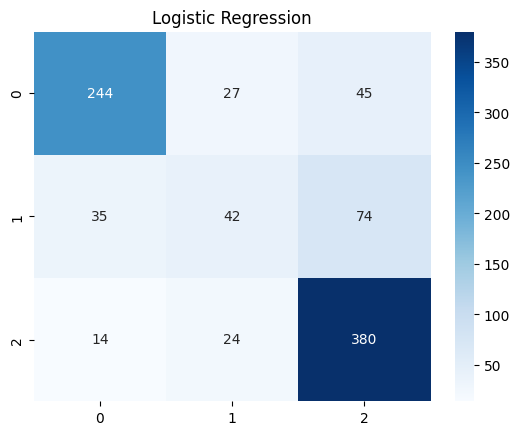


### Decision Tree
Accuracy: 0.7344632768361582


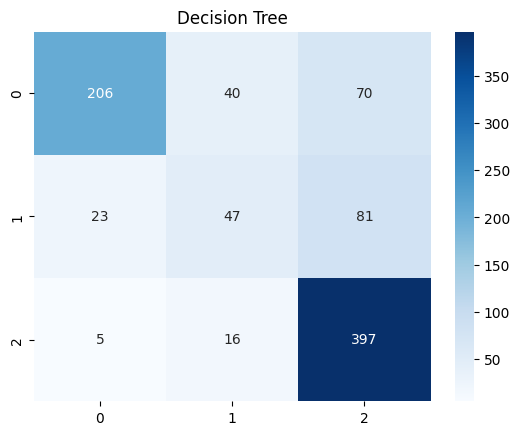


### KNN
Accuracy: 0.7016949152542373


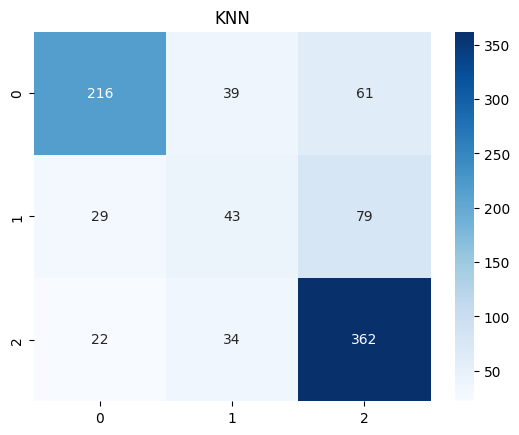


### Random Forest
Accuracy: 0.7593220338983051


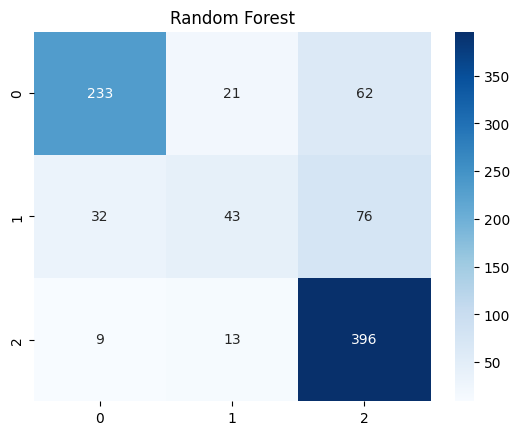

In [20]:
for name, model in models.items():
    print(f"\n### {name}")
    if name in ['KNN','Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title(name); plt.show()

### Select Best Model

This code selects the model with the highest cross-validation accuracy from results.
It then refits that best model on the full training data (scaled when needed) and prints its name.

In [21]:
best_model_name = max(results, key=lambda x: results[x][0])
best_model_name

'Logistic Regression'

In [22]:
best_model = models[best_model_name]
if best_model_name in ['KNN','Logistic Regression']:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)
print(f"Best model: {best_model_name}")

Best model: Logistic Regression


### Feature Importance (Tree Models Only)

This code checks whether the best model provides feature importance values.
If supported, it plots the top features; otherwise, it prints a message saying feature importance is unavailable.

In [23]:
if hasattr(best_model, 'feature_importances_'):
    feat = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    feat.head(10).plot(kind='bar'); plt.title('Top Features'); plt.show()
else:
    print("Model does not support feature importance.")

Model does not support feature importance.


### Save Best Model

Saves the best model in a pickle file

In [24]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved as best_model.pkl")

Model saved as best_model.pkl
